In [1]:
print(5+5)

10


In [2]:
import sys
sys.path.append('../../datasets')
#from spark_utils import *
import getpass
import pathlib
import os
import io
from tqdm import tqdm
from optuna.samplers import TPESampler
#import datadicts as dd
import pathlib
import sys
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import catboost as cb
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn import metrics
import optuna
import shap
#from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve
import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.preprocessing import LabelEncoder

/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:35: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _pt_shuffle_rec(i, indexes, index_mask, partition_tree, M, pos):
/opt/user-venvs/python3.8/lib64/python3.8/site-packages/shap/utils/_clustering.py:54: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def delta_minimization_order(al

In [3]:
import logging
import pandas as pd
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format='[%(asctime)s %(levelname)s - %(message)s]')

def normalize_column_names(data):
    logging.info("Приведение колонок к нижнему регистру")
    rename_map = {col: col.lower() for col in data.columns if col != col.lower()}
    return data.rename(columns=rename_map)

def remove_bad_columns(data):
    logging.info("Удаление плохих признаков")
    bad_columns = []
    
    # Исключаем epk_id из удаляемых колонок
    id_columns = list(filter(lambda x: x[-3:] in ["_id", "_dk"], data.columns))
    id_columns = [col for col in id_columns if col not in ["epk_id"]]  # сохраняем epk_id
    bad_columns += id_columns
    
    bad_columns += list(filter(lambda x: x[:4] in ["act"], data.columns))
    bad_columns += [col for col in data.columns if '_oi_' in col]
    
    bad_columns += [
          "ctl_loading"
        , "row_upd_dttm"
        , "prl_tax_payer_inn"
        , "prl_agrmnt_nbr"
        , "dep_payroll_bitmask_l12m_cd"
        , "dep_social_bitmask_l12m_cd"
        , "crd_lst_agrmnt_vsp_cd"
        , "crd_lst_agrmnt_osb_cd"
        , "prd_lst_prod_osb_cd"
        , 'birth_dt'
        , 'sd_age_mnth_comp_nv'            
        , 'sd_age_yrs_comp_nv'
        , 'data_type'
        , 'type'
        , 'sd_age_yrs_comp_nv'
        , 'crd_lst_agrmnt_tb_cd'
        , 'prl_tbholding_id'
        , 'dep_lst_payroll_agrmnt_id'
        , 'dep_acct_1st_division_dk'
        , 'dep_acct_lst_division_dk'
        , 'dep_acct_max_bal_division_dk'
        , 'prd_1st_prod_division_dk'
        , 'prd_lst_prod_division_dk'
        , 'seg_main_card_dwh_id'
        , 'tp_lst_division_dk'
        , 'crd_cc_lst_plastic_type_id'
        , 'crd_dc_lst_plastic_type_id'
        , 'prd_lst_prod_vsp_cd'
        , 'seg_crd_pos_cat_group'
        , 'seg_crm_segment_cd'
        , 'seg_client_cx_segment_cd'
        , 'seg_client_cx_criteria'
        , 'prl_tax_payer_inn'
        , 'prd_1st_prod_division_dk'
        , 'tp_lst_tb_cd'
        , 'tp_lst_kind_cd'
        , 'sd_dead_nflag'
    ]
    
    # Исключаем report_dt из удаляемых колонок
    if "report_dt" in bad_columns:
        bad_columns.remove("report_dt")
    
    bad_columns = list(set(bad_columns))
    bad_columns = [col for col in bad_columns if col in data.columns]
    
    logging.info(f"Удалено {len(bad_columns)} колонок: {bad_columns}")
    return data.drop(columns=bad_columns, errors="coerce")

def process_date_columns(data, report_col="report_dt"):
    logging.info("Преобразование datetime колонок в 'дни до report_dt'")
    
    if report_col not in data.columns:
        logging.warning(f"Колонка {report_col} отсутствует в данных")
        return data
    
    # Преобразуем report_dt в datetime
    data[report_col] = pd.to_datetime(data[report_col].astype(str), errors="coerce")
    
    # Находим все датовые колонки, исключая report_dt
    date_cols = [col for col in data.columns if "_dt" in col and col != report_col]
    
    # Также можно добавить другие колонки с датами по названию
    date_keywords = ['_date', '_dttm', '_time']
    for keyword in date_keywords:
        date_cols += [col for col in data.columns if keyword in col and col not in date_cols and col != report_col]
    
    date_cols = list(set(date_cols))
    
    logging.info(f"Найдено {len(date_cols)} датовых колонок для обработки")
    
    for col in tqdm(date_cols, desc="Обработка дат"):
        data[col] = pd.to_datetime(data[col].astype(str), errors="coerce")
        # Преобразуем в количество дней до report_dt
        data[col] = (data[report_col] - data[col]).dt.days
    
    # НЕ удаляем report_dt - просто возвращаем данные с этой колонкой
    return data

def fill_missing_values(data):
    # Теперь исключаем epk_id и report_dt из заполнения
    EXCLUDED_COLS = ["report_dt", "epk_id"]
    
    logging.info("Заполнение пропусков")
    fill_config = {
        "flg":               {"fill": -1,   "type": "int32"},
        "_qty":              {"fill": -999999},
        "_pct":              {"fill": -999999},
        "_days":             {"fill": -999999},
        "_num":              {"fill": -999999},
        "_amt":              {"fill": -999999},
        "_prc":              {"fill": -999999},
        "_rate":             {"fill": -999999,   "type": "float64"},
        "_frac":             {"fill": -999999,   "type": "float64"},
        "_nflag":            {"fill": -999999,   "type": "float64"},
        "_dt":               {"fill": -999999,   "type": "float64"},
        "float64":           {"fill": -999999},
        "int32":             {"fill": -999999},
        "object":            {"fill": 'UNKNOWN'}
    }
   
    for col in tqdm(data.columns, desc="Заполнение пропусков"):
        if col in EXCLUDED_COLS:
            continue
        
        col_handled = False
       
        for pattern, rule in fill_config.items():
            if pattern in col:
                fill_val = rule["fill"]
                dtype = rule.get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                col_handled = True
                break
               
        if not col_handled:
            col_type = str(data[col].dtype)
            if col_type in fill_config:
                fill_val = fill_config[col_type]["fill"]
                dtype = fill_config[col_type].get("type", None)
                data[col] = data[col].fillna(fill_val)
                if dtype:
                    data[col] = data[col].astype(dtype)
                   
    return data

def preprocess(data):
    logging.info("Старт предобработки")
    data = normalize_column_names(data)
    data = remove_bad_columns(data)
    data = process_date_columns(data, report_col="report_dt")
    data = fill_missing_values(data)
    cat_features = data.select_dtypes(include="object").columns.tolist()
    
    # Проверяем, что нужные колонки сохранились
    if "epk_id" not in data.columns:
        logging.warning("Колонка epk_id не найдена после предобработки!")
    if "report_dt" not in data.columns:
        logging.warning("Колонка report_dt не найдена после предобработки!")
    
    logging.info(f"Предобработка завершена. Число признаков: {data.shape[1]}")
    logging.info(f"Колонки сохранены: epk_id={'epk_id' in data.columns}, report_dt={'report_dt' in data.columns}")
    
    return data, cat_features

def prepare_dataset(train_df):
    logging.info("=== Запуск подготовки датасетов ===")
    train_df, cat_features = preprocess(train_df)
    logging.info(f"=== Подготовка завершена. Число признаков: {train_df.shape[1]} ===")
    return train_df, cat_features


In [4]:
def remove_corelated_features(df, threshold = 0.97, method = 'pearson'):
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df.columns.difference(numeric_cols).tolist()
    
    if not numeric_cols:
        return df
    
    corr_matrix = df[numeric_cols].corr(method = method).abs()
    parent = {}
    def find(u):
        while parent[u] != u:
            parent[u] = parent[parent[u]]
            u = parent[u]
        return u
    
    def union(u, v):
        root_u = find(u)
        root_v = find(v)
        if root_u != root_v:
            parent[root_v] = root_u
    
    for col in numeric_cols:
        parent[col] = col
        
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                col_i = corr_matrix.columns[i]
                col_j = corr_matrix.columns[j]
                union(col_i, col_j)
                
    groups = {}
    for col in numeric_cols:
        root = find(col)
        if root not in groups:
            groups[root] = []
        groups[root].append(col)
    
    selected = []
    for group in groups.values():
        best = max(group, key = lambda x: corr_matrix[x].sum())
        selected.append(best)
    
    result_cols = non_numeric_cols + selected
    
    result_cols = list(dict.fromkeys(result_cols))
    
    return result_cols

In [5]:
def cat_fi(model):
    cat_fi = pd.Series(
    data=model.feature_importances_,
    index=model.feature_names_,
    )
    fi = pd.DataFrame({"catboost_importance": cat_fi}).reset_index().sort_values(by = "catboost_importance", ascending = False)
    fi = fi.reset_index(drop = True)
    fi["desc"] = fi["index"].map(dd.FT_CLIENT_AGGR_MNTH)
    return fi

In [ ]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_v3_all_features_fix_types_train_for_model

In [7]:
!hdfs dfs -get hdfs://arnsdpsbx/user/team/team_ss/bpm_premier_multiclass_v4_oot_model_fixed

Picked up JAVA_TOOL_OPTIONS: -XX:ThreadStackSize=4096 -XX:VMThreadStackSize=4096


In [8]:
df = pd.read_parquet('bpm_premier_multiclass_v4_oot_model_fixed')

In [6]:
df = pd.read_parquet('bpm_premier_multiclass_v3_all_features_fix_types_train_for_model')

In [8]:
columns_to_drop = [col for col in df.columns if col.startswith('emb')]

df = df.drop(columns=columns_to_drop)

In [9]:
sample = df.sample(n=50000) 
cols = list(sample.columns)
feats = remove_corelated_features(sample[cols], threshold=0.97)

In [10]:
train_df = df[feats]

In [11]:
train_df.to_parquet('df_without_corr.parquet')

In [12]:
train_df, cat_features = prepare_dataset(train_df)

[2026-02-02 18:15:03,628 INFO - === Запуск подготовки датасетов ===]
[2026-02-02 18:15:03,629 INFO - Старт предобработки]
[2026-02-02 18:15:03,630 INFO - Приведение колонок к нижнему регистру]
[2026-02-02 18:15:05,083 INFO - Удаление плохих признаков]
[2026-02-02 18:15:05,084 INFO - Удалено 29 колонок: ['dep_lst_payroll_agrmnt_id', 'seg_client_cx_segment_cd', 'seg_crm_segment_cd', 'prl_subholding_id', 'row_upd_dttm', 'prd_1st_prod_division_dk', 'seg_crd_pos_cat_group', 'prd_lst_prod_vsp_cd', 'dep_social_bitmask_l12m_cd', 'prd_lst_prod_osb_cd', 'dep_acct_1st_division_dk', 'crd_lst_agrmnt_tb_cd', 'tp_lst_tb_cd', 'tp_lst_kind_cd', 'sd_dead_nflag', 'dep_payroll_bitmask_l12m_cd', 'dep_acct_max_bal_division_dk', 'crd_lst_agrmnt_vsp_cd', 'seg_client_cx_criteria', 'prl_holding_id', 'tp_lst_division_dk', 'crd_lst_agrmnt_osb_cd', 'prd_lst_prod_division_dk', 'prl_agrmnt_nbr', 'prl_tax_payer_inn', 'dep_acct_lst_division_dk', 'seg_main_card_dwh_id', 'actual_epk_id', 'prl_tbholding_id']]
[2026-02-02

In [10]:
train_df, cat_features = prepare_dataset(df)

[2026-03-19 10:26:46,937 INFO - === Запуск подготовки датасетов ===]
[2026-03-19 10:26:46,938 INFO - Старт предобработки]
[2026-03-19 10:26:46,939 INFO - Приведение колонок к нижнему регистру]
[2026-03-19 10:26:47,243 INFO - Удаление плохих признаков]
[2026-03-19 10:26:47,244 INFO - Удалено 0 колонок: []]
[2026-03-19 10:26:47,639 INFO - Преобразование datetime колонок в 'дни до report_dt']
[2026-03-19 10:26:47,785 INFO - Найдено 15 датовых колонок для обработки]
Обработка дат: 100%|██████████| 15/15 [00:05<00:00,  2.84it/s]
[2026-03-19 10:26:53,080 INFO - Заполнение пропусков]
Заполнение пропусков: 100%|██████████| 34/34 [00:00<00:00, 48.46it/s]
[2026-03-19 10:26:53,884 INFO - Предобработка завершена. Число признаков: 34]
[2026-03-19 10:26:53,885 INFO - Колонки сохранены: epk_id=True, report_dt=True]
[2026-03-19 10:26:53,885 INFO - === Подготовка завершена. Число признаков: 34 ===]


In [11]:
train_df.to_parquet('prep_data_v3_oot.parquet')

In [12]:
train_df = pd.read_parquet('prep_data_v3_oot.parquet')

In [35]:
cols = df[['epk_id']]
final_df = pd.concat([cols, train_df], axis=1)

In [44]:
cols_to_move = ['epk_id', 'report_dt', 'mon', 'target']
final_df = final_df[cols_to_move + [c for c in final_df.columns if c not in cols_to_move]]

In [26]:
final_df.duplicated().sum()

0

In [45]:
final_df.to_parquet('final_v3.parquet')

In [6]:
final_df = pd.read_parquet('final_v3.parquet')

In [13]:
final_df_oot = train_df.copy()

In [14]:
final_df_oot.to_parquet('final_v3_oot.parquet')

In [8]:
final_df_oot = pd.read_parquet('final_v3_oot.parquet')

# Catboost

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
pd.set_option('Display.max_columns', None)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
import sys
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance 
from catboost import CatBoostClassifier
from sklearn.metrics import roc_curve, RocCurveDisplay, roc_auc_score
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.model_selection import train_test_split
import catboost as ctb
from typing import Union
import optuna 
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix, precision_recall_curve, roc_curve, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from catboost import Pool

In [13]:
x = final_df.drop(columns=['target', 'mon', 'report_dt', 'epk_id'])
y = final_df['target']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.25, random_state = 0)

In [11]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [84]:
with open ('features_dict.pkl', 'rb') as f:
    feature_names = pickle.load(f)
    
from catboost import Pool

In [82]:
def get_pool(target_column = 'target', features = None):
    features = train.columns.tolist() if features is None else features
    categorical_columns = train[features].select_dtypes('object').columns.tolist()
    
    train_pool = ctb.Pool(data = train[features].drop(target_column, axis = 1, errors = 'ignore'), label = train[target_column], cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = val[features].drop(target_column, axis = 1, errors = 'ignore'), label = val[target_column],  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = test[features].drop(target_column, axis = 1, errors = 'ignore'), label = test[target_column],  cat_features = categorical_columns)
    
    return train_pool, val_pool, test_pool

def show_importances(model : Union[ctb.CatBoostClassifier, None], num : int = None) -> pd.DataFrame:
    importances = model.get_feature_importance(prettified=True)
    importances['Фичи'] = importances['Feature Id'].apply(lambda x: feature_names.get(x))
    if num:
        return importances.head(num)
    return importances.head(min(len(importances), 50))

## First iter

In [ ]:
prd_lst_prod_cd, seg_crd_segm_special_set_dt, tp_active_kind_cd, seg_premier_cd, seg_crd_segm_special_prev_cd, seg_client_mp_segment_cd, seg_client_rb_segment_cd, cla_dep_active_last_dt, sd_name_age_segment_cd, seg_client_sb_segment_cd, seg_name_age_cd, seg_service_channel_cd, seg_crd_segm_special_cd, prd_client_type_final_cd, tp_best_kind_ever_cd

In [53]:
x_train = x_train.drop(columns=['seg_service_channel_cd', 'seg_crd_segm_special_cd', 'prd_client_type_final_cd', 'tp_best_kind_ever_cd'])
x_val = x_val.drop(columns=['seg_service_channel_cd', 'seg_crd_segm_special_cd', 'prd_client_type_final_cd', 'tp_best_kind_ever_cd'])
x_test = x_test.drop(columns=['seg_service_channel_cd', 'seg_crd_segm_special_cd', 'prd_client_type_final_cd', 'tp_best_kind_ever_cd'])

In [54]:
text_columns = x_train.select_dtypes(include=['object']).columns.tolist()

In [55]:
train_pool = Pool(x_train, y_train, cat_features=text_columns)
val_pool = Pool(x_val, y_val, cat_features=text_columns)
test_pool = Pool(x_test, y_test, cat_features=text_columns)

In [56]:
#class_weights = [1, 2, 1, 2, 1]
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5381433	test: 1.5381966	best: 1.5381966 (0)	total: 31ms	remaining: 31s
100:	learn: 1.1107454	test: 1.1116348	best: 1.1116348 (100)	total: 2.32s	remaining: 20.7s
200:	learn: 1.0860904	test: 1.0883228	best: 1.0883228 (200)	total: 4.4s	remaining: 17.5s
300:	learn: 1.0744036	test: 1.0780878	best: 1.0780878 (300)	total: 6.49s	remaining: 15.1s
400:	learn: 1.0670371	test: 1.0722872	best: 1.0722872 (400)	total: 8.55s	remaining: 12.8s
500:	learn: 1.0612201	test: 1.0681216	best: 1.0681216 (500)	total: 10.6s	remaining: 10.6s
600:	learn: 1.0568627	test: 1.0652682	best: 1.0652682 (600)	total: 12.6s	remaining: 8.38s
700:	learn: 1.0537503	test: 1.0636457	best: 1.0636457 (700)	total: 14.5s	remaining: 6.2s
800:	learn: 1.0507029	test: 1.0619642	best: 1.0619642 (800)	total: 16.5s	remaining: 4.11s
900:	learn: 1.0482379	test: 1.0608625	best: 1.0608625 (900)	total: 18.5s	remaining: 2.03s
999:	learn: 1.0460048	test: 1.0599369	best: 1.0599369 (999)	total: 20.4s	remaining: 0us
bestTest = 1.05993691

In [57]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.846303991675816
VAL : 0.8414282829215071
TEST : 0.8399372940160761


In [58]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.49      0.25      0.33     29803
           2       0.63      0.68      0.65     60108
           3       0.59      0.60      0.60     30072
           4       0.53      0.63      0.57     54226
           5       0.53      0.53      0.53     29904

    accuracy                           0.57    204113
   macro avg       0.55      0.54      0.54    204113
weighted avg       0.56      0.57      0.56    204113



In [60]:
importances = model.get_feature_importance(prettified=True)

In [61]:
a = importances.loc[importances['Importances'] > 0.1, 'Feature Id'].tolist()

In [62]:
len(a)

96

## Second iter

In [63]:
x_train_new = x_train[a]
x_val_new = x_val[a]
x_test_new = x_test[a]

In [64]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [65]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [68]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5381429	test: 1.5381967	best: 1.5381967 (0)	total: 14.9ms	remaining: 14.9s
100:	learn: 1.1107790	test: 1.1116127	best: 1.1116127 (100)	total: 1.25s	remaining: 11.1s
200:	learn: 1.0852058	test: 1.0873423	best: 1.0873423 (200)	total: 2.44s	remaining: 9.7s
300:	learn: 1.0733223	test: 1.0769238	best: 1.0769238 (300)	total: 3.57s	remaining: 8.28s
400:	learn: 1.0658773	test: 1.0710309	best: 1.0710309 (400)	total: 4.68s	remaining: 6.99s
500:	learn: 1.0602808	test: 1.0670654	best: 1.0670654 (500)	total: 5.84s	remaining: 5.82s
600:	learn: 1.0560890	test: 1.0645045	best: 1.0645045 (600)	total: 7s	remaining: 4.65s
700:	learn: 1.0527878	test: 1.0626591	best: 1.0626591 (700)	total: 8.11s	remaining: 3.46s
800:	learn: 1.0494514	test: 1.0609028	best: 1.0609028 (800)	total: 9.24s	remaining: 2.29s
900:	learn: 1.0467784	test: 1.0597923	best: 1.0597923 (900)	total: 10.5s	remaining: 1.16s
999:	learn: 1.0443089	test: 1.0587990	best: 1.0587990 (999)	total: 11.7s	remaining: 0us
bestTest = 1.058798

In [69]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8466023362004849
VAL : 0.8416248476252688
TEST : 0.8401835563746523


In [70]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.49      0.26      0.33     29803
           2       0.63      0.67      0.65     60108
           3       0.60      0.60      0.60     30072
           4       0.53      0.63      0.58     54226
           5       0.53      0.52      0.52     29904

    accuracy                           0.57    204113
   macro avg       0.55      0.54      0.54    204113
weighted avg       0.56      0.57      0.56    204113



## Third iter 

In [72]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')

summary = model.select_features(train_pool, eval_set = val_pool,
                                features_for_select = x_train_new.drop('target', axis = 1, errors = 'ignore').columns.tolist(), 
                                steps = 5, 
                                verbose = 0,
                                num_features_to_select=50)


best_features = summary['selected_features_names']

Step #1 out of 5
bestTest = 1.058666014
bestIteration = 999
Feature #74 eliminated
Feature #65 eliminated
Feature #95 eliminated
Feature #84 eliminated
Feature #82 eliminated
Feature #83 eliminated
Feature #92 eliminated
Feature #94 eliminated
Feature #48 eliminated
Feature #86 eliminated
Feature #87 eliminated
Feature #88 eliminated
Step #2 out of 5
bestTest = 1.058843154
bestIteration = 998
Shrink model to first 999 iterations.
Feature #70 eliminated
Feature #69 eliminated
Feature #90 eliminated
Feature #73 eliminated
Feature #61 eliminated
Feature #56 eliminated
Feature #78 eliminated
Feature #58 eliminated
Feature #89 eliminated
Feature #46 eliminated
Step #3 out of 5
bestTest = 1.059646557
bestIteration = 999
Feature #26 eliminated
Feature #66 eliminated
Feature #71 eliminated
Feature #63 eliminated
Feature #45 eliminated
Feature #47 eliminated
Feature #91 eliminated
Feature #85 eliminated
Feature #28 eliminated
Step #4 out of 5
bestTest = 1.060550243
bestIteration = 999
Feature #

In [73]:
best_features

['seg_crm_spec_year_qty',
 'dep_inf_new_acct_qty_sum_6_9',
 'seg_age_segment',
 'dep_acc_lst_open_dt',
 'seg_client_fl_segment_cd',
 'dep_acct_dep_save_bal_rub_amt_sum_3_6',
 'cla_da_active_last_dt',
 'dep_acc_lst_close_dt',
 'prd_p2p_active_nflag',
 'srv_sbol_mob_3m_login_nflag',
 'crd_cc_utilization_pct',
 'srv_sbol_web_lst_login_ever_dt',
 'srv_sbol_lst_login_ever_dt',
 'prd_lst_prod_open_dt',
 'srv_sbol_mob_1st_login_dt',
 'lne_min_exp_pl_ann_dt',
 'dep_social_min_dt',
 'cla_crd_cc_active_last_dt',
 'sd_russian_citizen_nflag',
 'dep_upr_tot_bal_rub_amt',
 'dep_otf_intr_pmt_qty_sum_3m',
 'srv_sbol_mob_1st_login_ever_dt',
 'crd_cc_lst_os_amt',
 'srv_ap_cnbx_qty',
 'cla_inv_bo_active_last_dt',
 'tp_1st_open_dt',
 'dep_pens_plus_qty_sum_3_6',
 'srv_thanks_dt',
 'cla_curr_acc_active_last_dt',
 'dep_payroll_max_dt',
 'sd_gender_cd',
 'prd_auto_insurance_active_nflag',
 'srv_sbol_atm_lst_login_ever_dt',
 'dep_inf_social_rub_amt_sum_3_12',
 'prd_lst_prod_tb_cd',
 'lne_pl_max_close_dt',
 'd

In [74]:
x_train_new = x_train_new[best_features]
x_val_new = x_val_new[best_features]
x_test_new = x_test_new[best_features]

In [75]:
text_columns = x_train_new.select_dtypes(include=['object']).columns.tolist()

In [76]:
train_pool = Pool(x_train_new, y_train, cat_features=text_columns)
val_pool = Pool(x_val_new, y_val, cat_features=text_columns)
test_pool = Pool(x_test_new, y_test, cat_features=text_columns)

In [77]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass',
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5381463	test: 1.5381975	best: 1.5381975 (0)	total: 12.5ms	remaining: 12.5s
100:	learn: 1.1117200	test: 1.1126688	best: 1.1126688 (100)	total: 1.06s	remaining: 9.42s
200:	learn: 1.0873818	test: 1.0893957	best: 1.0893957 (200)	total: 2.15s	remaining: 8.53s
300:	learn: 1.0763454	test: 1.0797875	best: 1.0797875 (300)	total: 3.2s	remaining: 7.44s
400:	learn: 1.0693557	test: 1.0743340	best: 1.0743340 (400)	total: 4.22s	remaining: 6.31s
500:	learn: 1.0644329	test: 1.0709655	best: 1.0709655 (500)	total: 5.26s	remaining: 5.24s
600:	learn: 1.0605675	test: 1.0686208	best: 1.0686208 (600)	total: 6.25s	remaining: 4.15s
700:	learn: 1.0573057	test: 1.0668919	best: 1.0668919 (700)	total: 7.27s	remaining: 3.1s
800:	learn: 1.0544122	test: 1.0655095	best: 1.0655095 (800)	total: 8.32s	remaining: 2.07s
900:	learn: 1.0520490	test: 1.0645451	best: 1.0645451 (900)	total: 9.33s	remaining: 1.02s
999:	learn: 1.0498250	test: 1.0637773	best: 1.0637773 (999)	total: 10.3s	remaining: 0us
bestTest = 1.0637

In [13]:
def simple_train(target_column = 'target', features = None, model_params = None):
    features = x_train.columns.tolist() if features is None else features
    categorical_columns = x_train[features].select_dtypes('object').columns.tolist()
    
    
    train_pool = ctb.Pool(data = x_train_new[features], label = y_train, cat_features = categorical_columns)
    val_pool  = ctb.Pool(data = x_val_new[features], label = y_val,  cat_features = categorical_columns)
    test_pool  = ctb.Pool(data = x_test_new[features], label = y_test,  cat_features = categorical_columns)

    model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
        
    model.fit(train_pool, eval_set = val_pool)
    
    
    train_preds = model.predict(train_pool)
    train_probas = model.predict_proba(train_pool)
    
    val_preds = model.predict(val_pool)
    val_probas = model.predict_proba(val_pool)
    
    
    test_preds = model.predict(test_pool)
    test_probas = model.predict_proba(test_pool)
    
    
    
    return train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model

In [83]:
target_column = 'target' 
RANDOM_SEED = 0

train_roc_auc = []
val_roc_auc = []
test_roc_auc = []


train_f1 = []
val_f1 = []
test_f1 = []


importances  = show_importances(model, -1)['Feature Id'].tolist()

xticks = range(1, len(best_features), 3)

for num_features in tqdm(xticks):
    used_features = importances[: num_features]
    
    
    train_preds, train_probas, val_preds, val_probas, test_preds, test_probas, model_temp = simple_train(target_column, used_features)

    # train_f1.append(f1_score(train[target_column], train_preds))
    # val_f1.append(f1_score(val[target_column], val_preds))
    # test_f1.append(f1_score(test[target_column], test_preds))


    train_roc_auc.append(roc_auc_score(y_train, train_probas, multi_class = 'ovr', average = 'macro'))
    val_roc_auc.append(roc_auc_score(y_val, val_probas, multi_class = 'ovr', average = 'macro'))
    test_roc_auc.append(roc_auc_score(y_test, test_probas, multi_class = 'ovr', average = 'macro'))

  0%|          | 0/17 [00:00<?, ?it/s]

0:	learn: 1.5812972	test: 1.5815125	best: 1.5815125 (0)	total: 5.58ms	remaining: 5.58s
bestTest = 1.457711024
bestIteration = 57
Shrink model to first 58 iterations.


  6%|▌         | 1/17 [00:03<01:03,  3.98s/it]

0:	learn: 1.5586672	test: 1.5587896	best: 1.5587896 (0)	total: 10.3ms	remaining: 10.3s
100:	learn: 1.2438012	test: 1.2439485	best: 1.2439485 (100)	total: 869ms	remaining: 7.74s
200:	learn: 1.2415604	test: 1.2422558	best: 1.2422558 (200)	total: 1.72s	remaining: 6.83s
300:	learn: 1.2406217	test: 1.2417574	best: 1.2417574 (300)	total: 2.58s	remaining: 5.99s
400:	learn: 1.2400140	test: 1.2415687	best: 1.2415687 (400)	total: 3.46s	remaining: 5.18s
500:	learn: 1.2394852	test: 1.2414340	best: 1.2414327 (497)	total: 4.35s	remaining: 4.33s
600:	learn: 1.2390587	test: 1.2413878	best: 1.2413796 (581)	total: 5.2s	remaining: 3.45s
700:	learn: 1.2386782	test: 1.2413665	best: 1.2413568 (693)	total: 6.05s	remaining: 2.58s
bestTest = 1.241356844
bestIteration = 693
Shrink model to first 694 iterations.


 12%|█▏        | 2/17 [00:15<02:04,  8.32s/it]

...

 88%|████████▊ | 15/17 [03:39<00:32, 16.35s/it]

0:	learn: 1.5381459	test: 1.5381970	best: 1.5381970 (0)	total: 11.8ms	remaining: 11.8s
100:	learn: 1.1112046	test: 1.1123149	best: 1.1123149 (100)	total: 1.03s	remaining: 9.13s
200:	learn: 1.0878105	test: 1.0901220	best: 1.0901220 (200)	total: 2.02s	remaining: 8.01s
300:	learn: 1.0771598	test: 1.0808264	best: 1.0808264 (300)	total: 3.01s	remaining: 6.98s
400:	learn: 1.0704909	test: 1.0756457	best: 1.0756457 (400)	total: 4.02s	remaining: 6s
500:	learn: 1.0656311	test: 1.0723352	best: 1.0723352 (500)	total: 5.03s	remaining: 5.01s
600:	learn: 1.0618297	test: 1.0700133	best: 1.0700133 (600)	total: 6.02s	remaining: 4s
700:	learn: 1.0586640	test: 1.0683009	best: 1.0683009 (700)	total: 7.03s	remaining: 3s
800:	learn: 1.0559976	test: 1.0670503	best: 1.0670503 (800)	total: 8.02s	remaining: 1.99s
900:	learn: 1.0537322	test: 1.0661226	best: 1.0661216 (899)	total: 9.01s	remaining: 990ms
999:	learn: 1.0516525	test: 1.0653892	best: 1.0653892 (999)	total: 9.97s	remaining: 0us
bestTest = 1.065389192
b

 94%|█████████▍| 16/17 [03:56<00:16, 16.72s/it]

0:	learn: 1.5381458	test: 1.5381975	best: 1.5381975 (0)	total: 11.9ms	remaining: 11.9s
100:	learn: 1.1116920	test: 1.1126018	best: 1.1126018 (100)	total: 1.04s	remaining: 9.29s
200:	learn: 1.0877840	test: 1.0898765	best: 1.0898765 (200)	total: 2.06s	remaining: 8.18s
300:	learn: 1.0766533	test: 1.0801750	best: 1.0801750 (300)	total: 3.08s	remaining: 7.15s
400:	learn: 1.0696324	test: 1.0746922	best: 1.0746922 (400)	total: 4.1s	remaining: 6.13s
500:	learn: 1.0648594	test: 1.0714497	best: 1.0714497 (500)	total: 5.11s	remaining: 5.09s
600:	learn: 1.0608614	test: 1.0689424	best: 1.0689424 (600)	total: 6.12s	remaining: 4.06s
700:	learn: 1.0578233	test: 1.0674082	best: 1.0674082 (700)	total: 7.13s	remaining: 3.04s
800:	learn: 1.0549291	test: 1.0660631	best: 1.0660631 (800)	total: 8.15s	remaining: 2.02s
900:	learn: 1.0526682	test: 1.0652112	best: 1.0652110 (899)	total: 9.18s	remaining: 1.01s
999:	learn: 1.0504949	test: 1.0644259	best: 1.0644253 (997)	total: 10.2s	remaining: 0us
bestTest = 1.064

100%|██████████| 17/17 [04:14<00:00, 14.98s/it]


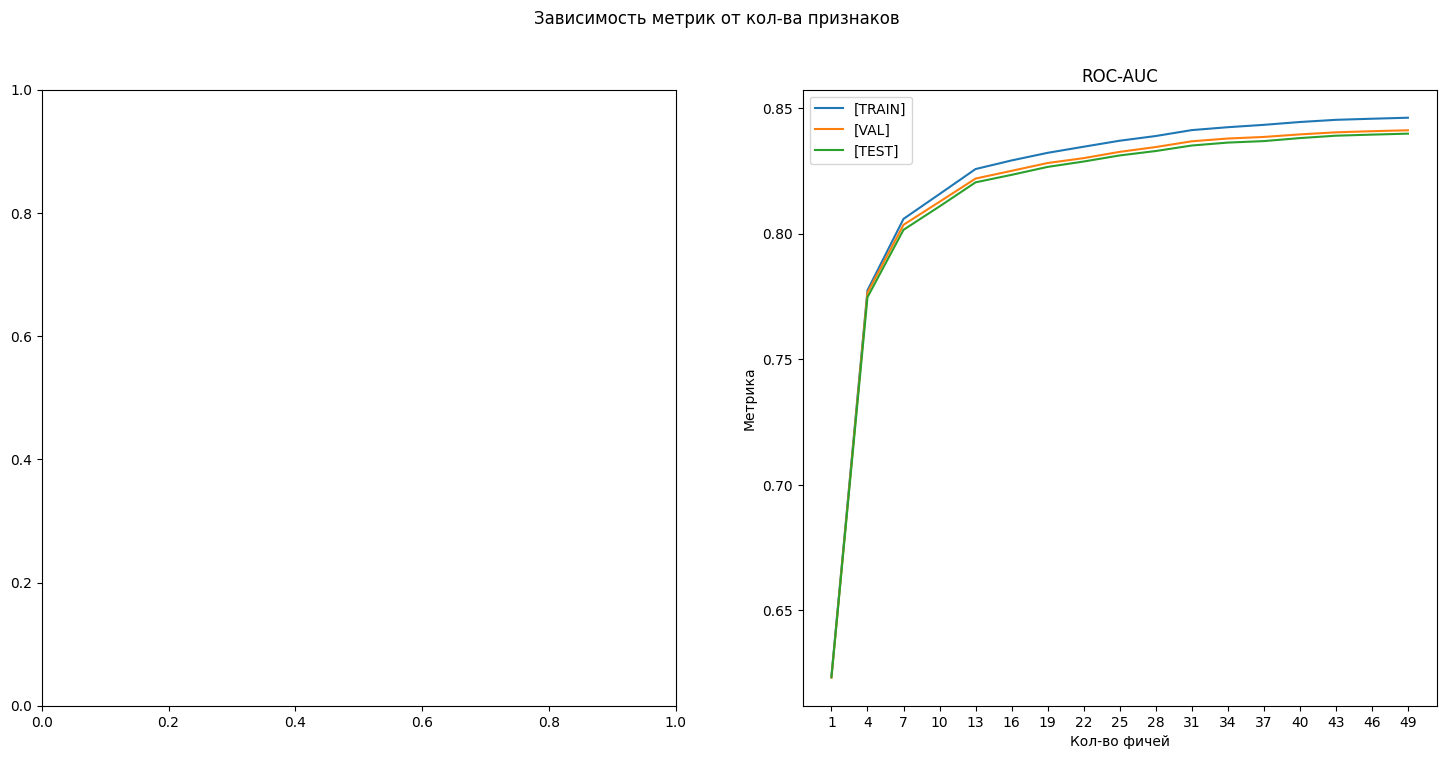

In [84]:
fig, axs = plt.subplots(ncols = 2, figsize = (18, 8), )

fig.suptitle('Зависимость метрик от кол-ва признаков')


plt.title('Метрики от кол-ва фичей')
plt.ylabel('Метрика')
plt.xlabel('Кол-во фичей')


# axs[0].plot(train_f1, label = '[TRAIN]')
# axs[0].plot(val_f1, label = '[VAL]')
# axs[0].plot(test_f1, label = '[TEST]')

# axs[0].set_title('F1')
# axs[0].set_xticks(ticks = list(range(len(train_f1))), labels = xticks)
# axs[0].set_xlabel('Кол-во фичей')
# axs[0].set_ylabel('Метрика')




axs[1].plot(train_roc_auc, label = '[TRAIN]')
axs[1].plot(val_roc_auc, label = '[VAL]')
axs[1].plot(test_roc_auc, label = '[TEST]')

axs[1].set_title('ROC-AUC')
axs[1].set_xlabel('Кол-во фичей')
axs[1].set_ylabel('Метрика')

axs[1].set_xticks(ticks = list(range(len(train_roc_auc))), labels = xticks)


axs[1].legend();

In [95]:
num_features = 31
final_features = importances[:num_features]

In [96]:
final_features

['seg_crm_spec_year_qty',
 'dep_inf_new_acct_qty_sum_6_9',
 'seg_age_segment',
 'dep_acc_lst_open_dt',
 'seg_client_fl_segment_cd',
 'dep_acct_dep_save_bal_rub_amt_sum_3_6',
 'cla_da_active_last_dt',
 'dep_acc_lst_close_dt',
 'prd_p2p_active_nflag',
 'srv_sbol_mob_3m_login_nflag',
 'crd_cc_utilization_pct',
 'srv_sbol_web_lst_login_ever_dt',
 'srv_sbol_lst_login_ever_dt',
 'prd_lst_prod_open_dt',
 'srv_sbol_mob_1st_login_dt',
 'dep_inf_social_rub_amt_sum_3_12',
 'sd_russian_citizen_nflag',
 'lne_min_exp_pl_ann_dt',
 'cla_crd_cc_active_last_dt',
 'dep_social_min_dt',
 'srv_sbol_mob_1st_login_ever_dt',
 'srv_sbol_txn_web_1m_qty_sum_3_9',
 'dep_otf_intr_pmt_qty_sum_3m',
 'dep_pens_plus_qty_sum_3_6',
 'dep_payroll_max_dt',
 'tp_1st_open_dt',
 'dep_upr_tot_bal_rub_amt',
 'crd_cc_lst_os_amt',
 'srv_ap_cnbx_qty',
 'srv_thanks_dt',
 'cla_inv_bo_active_last_dt']

In [11]:
final_features = ['seg_crm_spec_year_qty',
 'dep_inf_new_acct_qty_sum_6_9',
 'seg_age_segment',
 'dep_acc_lst_open_dt',
 'seg_client_fl_segment_cd',
 'dep_acct_dep_save_bal_rub_amt_sum_3_6',
 'cla_da_active_last_dt',
 'dep_acc_lst_close_dt',
 'prd_p2p_active_nflag',
 'srv_sbol_mob_3m_login_nflag',
 'crd_cc_utilization_pct',
 'srv_sbol_web_lst_login_ever_dt',
 'srv_sbol_lst_login_ever_dt',
 'prd_lst_prod_open_dt',
 'srv_sbol_mob_1st_login_dt',
 'dep_inf_social_rub_amt_sum_3_12',
 'sd_russian_citizen_nflag',
 'lne_min_exp_pl_ann_dt',
 'cla_crd_cc_active_last_dt',
 'dep_social_min_dt',
 'srv_sbol_mob_1st_login_ever_dt',
 'srv_sbol_txn_web_1m_qty_sum_3_9',
 'dep_otf_intr_pmt_qty_sum_3m',
 'dep_pens_plus_qty_sum_3_6',
 'dep_payroll_max_dt',
 'tp_1st_open_dt',
 'dep_upr_tot_bal_rub_amt',
 'crd_cc_lst_os_amt',
 'srv_ap_cnbx_qty',
 'srv_thanks_dt',
 'cla_inv_bo_active_last_dt']

## Last

In [15]:
x_train_last = x_train[final_features]
x_val_last = x_val[final_features]
x_test_last = x_test[final_features]

In [23]:
text_columns = x_train_last.select_dtypes(include=['object']).columns.tolist()

In [24]:
train_pool = Pool(x_train_last, y_train, cat_features=text_columns)
val_pool = Pool(x_val_last, y_val, cat_features=text_columns)
test_pool = Pool(x_test_last, y_test, cat_features=text_columns)

In [19]:
#text_columns_oot = train_df_oot.drop(columns='target').select_dtypes(include=['object']).columns.tolist()
#x = train_df_oot.drop(columns=['target', 'report_dt', 'epk_id'])
#y = train_df_oot['target']
#oot_pool = Pool(x, y, cat_features=text_columns_oot)

In [20]:
model = ctb.CatBoostClassifier(iterations=1000, depth=5, learning_rate = 0.1, 
                               verbose=100, task_type = 'GPU', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5381463	test: 1.5381969	best: 1.5381969 (0)	total: 17.7ms	remaining: 17.6s
100:	learn: 1.1147867	test: 1.1153759	best: 1.1153759 (100)	total: 965ms	remaining: 8.59s
200:	learn: 1.0951501	test: 1.0968378	best: 1.0968378 (200)	total: 1.88s	remaining: 7.47s
300:	learn: 1.0862131	test: 1.0892487	best: 1.0892487 (300)	total: 2.77s	remaining: 6.43s
400:	learn: 1.0807786	test: 1.0851930	best: 1.0851930 (400)	total: 3.67s	remaining: 5.48s
500:	learn: 1.0768247	test: 1.0825090	best: 1.0825090 (500)	total: 4.55s	remaining: 4.53s
600:	learn: 1.0737601	test: 1.0808635	best: 1.0808635 (600)	total: 5.44s	remaining: 3.61s
700:	learn: 1.0710332	test: 1.0794262	best: 1.0794262 (700)	total: 6.32s	remaining: 2.7s
800:	learn: 1.0688249	test: 1.0784990	best: 1.0784990 (800)	total: 7.2s	remaining: 1.79s
900:	learn: 1.0668877	test: 1.0777567	best: 1.0777567 (900)	total: 8.09s	remaining: 888ms
999:	learn: 1.0650867	test: 1.0771454	best: 1.0771454 (999)	total: 8.97s	remaining: 0us
bestTest = 1.0771

In [21]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
#print(f"OOT : {roc_auc_score(y, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8395574621711754
VAL : 0.8353723027572821
TEST : 0.8336763302201425


In [22]:
print(classification_report(y_test, model.predict(test_pool)))

              precision    recall  f1-score   support

           1       0.48      0.24      0.32     29803
           2       0.62      0.67      0.65     60108
           3       0.59      0.60      0.60     30072
           4       0.52      0.63      0.57     54226
           5       0.53      0.51      0.52     29904

    accuracy                           0.56    204113
   macro avg       0.55      0.53      0.53    204113
weighted avg       0.56      0.56      0.55    204113



In [249]:
low, high = -1, 100000000

features = final_features = ['seg_crm_spec_year_qty',
'dep_inf_new_acct_qty_sum_6_9',
'dep_acc_lst_open_dt',
'dep_acct_dep_save_bal_rub_amt_sum_3_6',
'cla_da_active_last_dt',
'dep_acc_lst_close_dt',
'srv_sbol_mob_3m_login_nflag',
'prd_p2p_active_nflag',
'crd_cc_utilization_pct',
'srv_sbol_lst_login_ever_dt',
'srv_sbol_web_lst_login_ever_dt',
'dep_inf_social_rub_amt_sum_3_12',
'srv_sbol_mob_1st_login_ever_dt',
'prd_lst_prod_open_dt',
'srv_sbol_mob_1st_login_dt',
'lne_min_exp_pl_ann_dt',
'cla_crd_cc_active_last_dt',
'dep_social_min_dt',
'sd_russian_citizen_nflag',
'dep_payroll_max_dt',
'tp_1st_open_dt',
'srv_thanks_dt',
'srv_sbol_txn_web_1m_qty_sum_3_9',
'dep_pens_plus_qty_sum_3_6',
'dep_otf_intr_pmt_qty_sum_3m',
'srv_ap_cnbx_qty',
'crd_cc_lst_os_amt',
'dep_upr_tot_bal_rub_amt']
                                                                          
                                                                          
means = {}

for feat in final_features:
    s = final_df[feat].where(final_df[feat].gt(low) & final_df[feat].lt(high))
    
    means[feat] = s.groupby(final_df['target']).mean()

result = pd.DataFrame(means)

In [250]:
result

,seg_crm_spec_year_qty,dep_inf_new_acct_qty_sum_6_9,dep_acc_lst_open_dt,dep_acct_dep_save_bal_rub_amt_sum_3_6,cla_da_active_last_dt,dep_acc_lst_close_dt,srv_sbol_mob_3m_login_nflag,prd_p2p_active_nflag,crd_cc_utilization_pct,srv_sbol_lst_login_ever_dt,srv_sbol_web_lst_login_ever_dt,dep_inf_social_rub_amt_sum_3_12,srv_sbol_mob_1st_login_ever_dt,prd_lst_prod_open_dt,srv_sbol_mob_1st_login_dt,lne_min_exp_pl_ann_dt,cla_crd_cc_active_last_dt,dep_social_min_dt,sd_russian_citizen_nflag,dep_payroll_max_dt,tp_1st_open_dt,srv_thanks_dt,srv_sbol_txn_web_1m_qty_sum_3_9,dep_pens_plus_qty_sum_3_6,dep_otf_intr_pmt_qty_sum_3m,srv_ap_cnbx_qty,crd_cc_lst_os_amt,dep_upr_tot_bal_rub_amt
target,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.131615,1.043524,472.540898,1.154293,38.429552,615.916090,0.707799,0.684310,0.247718,24.837162,189.879131,1.108247,2126.073286,276.478240,27.590690,1398.382609,456.380143,3185.135795,0.990391,556.576501,1165.275398,2200.568139,1.005592,0.995548,130.514885,0.189402,93621.851904,33790.015551
2,0.118156,1.006127,430.086349,1.136511,35.573461,577.509606,0.936892,0.943227,0.185620,4.449692,314.379423,1.115268,2396.082162,248.533072,28.179173,1708.358491,549.487866,2542.936959,0.993194,343.695402,1328.114276,2447.457422,0.932706,0.988657,202.272385,0.193727,100262.140932,45873.268047
3,0.148279,1.046906,660.074271,1.149813,38.312177,681.962687,0.388537,0.372066,0.222806,58.313044,157.794836,1.069612,1781.168029,380.338239,26.399032,1375.452830,600.034678,3498.746353,0.991029,876.701343,1019.570081,1904.880265,1.020674,0.998434,52.430017,0.106523,77337.196218,26449.073341
4,0.125723,0.995898,1177.322646,1.081943,118.405909,1176.074011,0.900452,0.882948,0.278589,12.212786,321.238668,1.089154,2330.249431,511.716575,27.622834,1399.714286,477.223913,2673.127645,0.985711,438.753641,1110.986394,2239.206680,0.965747,0.994742,30.935327,0.146032,141096.006947,27618.398000
5,0.126012,0.997588,2005.476773,1.129572,178.047747,1716.725512,0.751537,0.757964,0.400869,39.486056,311.534911,1.122254,2299.455364,918.749014,28.131024,1352.186630,264.867225,2633.457918,0.927133,489.736790,655.092360,2119.732070,1.013810,0.997303,17.012704,0.267626,119346.174377,12866.702797


In [ ]:
x_test_last = x_test[final_features]

In [25]:
percentiles = [0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

In [74]:
X = x_test_last
y_true = pd.Series(y_test).astype(str).str.strip().to_numpy()
proba = model.predict_proba(X)
classes = pd.Series(model.classes_).astype(str).str.strip().to_numpy()

y_true = y_true.astype(int)
classes = classes.astype(int)

rows_new = []
results_df_new = []
n = len(y_true)

In [75]:
for i, cls in enumerate(classes):
    y_score = proba[:, i]
    y_bin = (y_true == cls).astype(int)
    
    print(f"class {repr(cls)}positives:", int(y_bin.sum()))
    
    if y_bin.sum() == 0:
        continue
    
    base_rate = y_bin.mean()
    
    for p in percentiles:
        k = max(1, int(n*p))
        idx = np.argsort(y_score)[-k:]
        
        y_pred = np.zeros(n, dtype=int)
        y_pred[idx] = 1
        
        n_samples = k
    
        precision = precision_score(y_bin, y_pred, zero_division=0)
        recall = recall_score(y_bin, y_pred, zero_division=0)
        f1 = 2 * ((precision*recall)/(precision+recall))
        lift = precision/base_rate if base_rate > 0 else np.nan
    
        rows_new.append({
            'Class': cls,
            'Share': p * 100,
            'Subsample': n_samples,
            'Precision': precision,
            'Recall': recall,
            'F1_score':f1,
            'Min_score': np.min(y_score[idx]),
            'Lift': lift
        })
        # break
    
results_df_new = pd.DataFrame(rows_new)

class 1positives: 29803
class 2positives: 60108
class 3positives: 30072
class 4positives: 54226
class 5positives: 29904


In [76]:
results_df_new

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
0,1,1.0,2041,0.697207,0.047747,0.089373,0.617686,4.774991
1,1,3.0,6123,0.599216,0.123108,0.204253,0.493911,4.103875
2,1,5.0,10205,0.540519,0.185082,0.275745,0.425400,3.701877
3,1,10.0,20411,0.459311,0.314566,0.373402,0.330044,3.145703
4,1,20.0,40822,0.372397,0.510083,0.430499,0.249648,2.550452
...,...,...,...,...,...,...,...,...
60,5,60.0,122467,0.233157,0.954856,0.374796,0.040423,1.591436
61,5,70.0,142879,0.204222,0.975756,0.337753,0.025635,1.393938
62,5,80.0,163290,0.180973,0.988196,0.305920,0.015569,1.235247
63,5,90.0,183701,0.162155,0.996121,0.278907,0.008792,1.106805


In [78]:
results_df_new[results_df_new['Class'] == 1] # Сурен сказал 20%

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
0,1,1.0,2041,0.697207,0.047747,0.089373,0.617686,4.774991
1,1,3.0,6123,0.599216,0.123108,0.204253,0.493911,4.103875
2,1,5.0,10205,0.540519,0.185082,0.275745,0.425400,3.701877
3,1,10.0,20411,0.459311,0.314566,0.373402,0.330044,3.145703
4,1,20.0,40822,0.372397,0.510083,0.430499,0.249648,2.550452
5,1,30.0,61233,0.319207,0.655840,0.429413,0.184218,2.186166
6,1,40.0,81645,0.276208,0.756669,0.404691,0.128547,1.891677
7,1,50.0,102056,0.243337,0.833272,0.376675,0.095026,1.666552
8,1,60.0,122467,0.216965,0.891555,0.348998,0.071268,1.485934
9,1,70.0,142879,0.194647,0.933161,0.322107,0.053384,1.333088


In [79]:
results_df_new[results_df_new['Class'] == 2]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
13,2,1.0,2041,0.924547,0.031393,0.060725,0.899493,3.139549
14,2,3.0,6123,0.899232,0.091602,0.166267,0.842602,3.053587
15,2,5.0,10205,0.875257,0.148599,0.254064,0.799992,2.972173
16,2,10.0,20411,0.819901,0.278416,0.415678,0.712478,2.784196
17,2,20.0,40822,0.726202,0.493196,0.587437,0.553710,2.466014
18,2,30.0,61233,0.642921,0.654954,0.648882,0.407866,2.183213
19,2,40.0,81645,0.566881,0.769997,0.653009,0.289189,1.924998
20,2,50.0,102056,0.502508,0.853198,0.632495,0.211001,1.706404
21,2,60.0,122467,0.448978,0.914770,0.602328,0.158781,1.524627
22,2,70.0,142879,0.404237,0.960887,0.569071,0.112054,1.372697


In [80]:
results_df_new[results_df_new['Class'] == 3]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
26,3,1.0,2041,0.740323,0.050246,0.094105,0.730882,5.024928
27,3,3.0,6123,0.736894,0.150040,0.249316,0.700393,5.001649
28,3,5.0,10205,0.715140,0.242684,0.362390,0.671924,4.853994
29,3,10.0,20411,0.668855,0.453977,0.540855,0.543311,4.539838
30,3,20.0,40822,0.520969,0.707203,0.599966,0.219625,3.536066
31,3,30.0,61233,0.402528,0.819633,0.539905,0.116955,2.732150
32,3,40.0,81645,0.325690,0.884244,0.476042,0.074725,2.210617
33,3,50.0,102056,0.273321,0.927574,0.422227,0.052418,1.855157
34,3,60.0,122467,0.235263,0.958101,0.377766,0.037527,1.596845
35,3,70.0,142879,0.206006,0.978784,0.340374,0.026431,1.398264


In [81]:
results_df_new[results_df_new['Class'] == 4]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
39,4,1.0,2041,0.777560,0.029266,0.056410,0.767995,2.926827
40,4,3.0,6123,0.740323,0.083595,0.150226,0.706890,2.786664
41,4,5.0,10205,0.716610,0.134862,0.227003,0.662827,2.697402
42,4,10.0,20411,0.666111,0.250728,0.364323,0.580399,2.507321
43,4,20.0,40822,0.595194,0.448069,0.511257,0.467421,2.240379
44,4,30.0,61233,0.540248,0.610058,0.573035,0.380655,2.033556
45,4,40.0,81645,0.491873,0.740586,0.591134,0.296249,1.851469
46,4,50.0,102056,0.446206,0.839782,0.582767,0.220617,1.679572
47,4,60.0,122467,0.403962,0.912330,0.559977,0.159344,1.520560
48,4,70.0,142879,0.364301,0.959890,0.528155,0.105666,1.371273


In [82]:
results_df_new[results_df_new['Class'] == 5]

,Class,Share,Subsample,Precision,Recall,F1_score,Min_score,Lift
52,5,1.0,2041,0.898089,0.061296,0.114760,0.779838,6.130005
53,5,3.0,6123,0.781153,0.159945,0.265523,0.634404,5.331845
54,5,5.0,10205,0.706712,0.241172,0.359620,0.548433,4.823742
55,5,10.0,20411,0.591838,0.403959,0.480175,0.423093,4.039653
56,5,20.0,40822,0.460903,0.629180,0.532053,0.259942,3.145946
57,5,30.0,61233,0.377770,0.773542,0.507631,0.165102,2.578511
58,5,40.0,81645,0.316480,0.864065,0.463276,0.100681,2.160168
59,5,50.0,102056,0.269852,0.920947,0.417399,0.063183,1.841903
60,5,60.0,122467,0.233157,0.954856,0.374796,0.040423,1.591436
61,5,70.0,142879,0.204222,0.975756,0.337753,0.025635,1.393938


## Optuna

In [24]:
def objective(trial):
    param = {
        "n_estimators": trial.suggest_int('n_estimators', 100, 2000),
        "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-2, 10),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 1.0),
        "min_child_samples": trial.suggest_float("min_child_samples", 100, 1000, step=100),
        "grow_policy": trial.suggest_categorical("grow_policy", ['SymmetricTree', 'Depthwise', 'Lossguide']),
        "border_count": trial.suggest_categorical("border_count", [128, 256, 512, 1024]),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    }
    
    acw = trial.suggest_categorical("auto_class_weights", [None, 'Balanced', 'SqrtBalanced'])
    if acw is not None:
        param['auto_class_weights'] = acw
    
    
    model = CatBoostClassifier(**param, verbose=False, loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=30, eval_metric = 'MultiClass',  cat_features = text_columns)
        
    model.fit(train_pool, eval_set = val_pool, early_stopping_rounds=50, plot=False)
    
    val_roc_auc = roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')
    
    train_roc_auc = roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')
    
    if train_roc_auc - val_roc_auc > 0.02:
        return 0
    else:
        return val_roc_auc

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=150)

In [17]:
x_oot = final_df_oot.drop(columns=['epk_id', 'report_dt', 'target'])
y_oot = final_df_oot['target']

In [18]:
text_columns = x_oot.select_dtypes(include=['object']).columns.tolist()

In [27]:
oot_pool = Pool(x_oot, y_oot, cat_features=text_columns)

In [28]:
final_df_oot['target'].value_counts()

target
5    607657
2    577935
1    211664
3     95559
4     93884
Name: count, dtype: int64

In [29]:
# i can not show parameters, because i am under NDA
model = ctb.CatBoostClassifier(n_estimators=x, depth=x, learning_rate = x, l2_leaf_reg=x, 
                               colsample_bylevel=x, min_child_samples=x, grow_policy='x', border_count=x,
                               auto_class_weights='x', loss_function='MultiClass', 
                               random_seed=0, early_stopping_rounds=x, eval_metric='MultiClass')
model.fit(train_pool, eval_set = val_pool)

0:	learn: 1.5101231	test: 1.5102979	best: 1.5102979 (0)	total: 422ms	remaining: 12m
1:	learn: 1.4388691	test: 1.4390643	best: 1.4390643 (1)	total: 807ms	remaining: 11m 27s
2:	learn: 1.3945810	test: 1.3946841	best: 1.3946841 (2)	total: 1.18s	remaining: 11m 7s
3:	learn: 1.3533909	test: 1.3534423	best: 1.3534423 (3)	total: 1.54s	remaining: 10m 57s
4:	learn: 1.3219963	test: 1.3220351	best: 1.3220351 (4)	total: 1.89s	remaining: 10m 43s
5:	learn: 1.2963405	test: 1.2964096	best: 1.2964096 (5)	total: 2.2s	remaining: 10m 22s
6:	learn: 1.2754584	test: 1.2755386	best: 1.2755386 (6)	total: 2.59s	remaining: 10m 28s
7:	learn: 1.2564054	test: 1.2565203	best: 1.2565203 (7)	total: 3.01s	remaining: 10m 38s
8:	learn: 1.2426725	test: 1.2428244	best: 1.2428244 (8)	total: 3.37s	remaining: 10m 36s
9:	learn: 1.2296991	test: 1.2298985	best: 1.2298985 (9)	total: 3.71s	remaining: 10m 29s
10:	learn: 1.2198553	test: 1.2200467	best: 1.2200467 (10)	total: 4.13s	remaining: 10m 37s
11:	learn: 1.2110532	test: 1.2112602

In [30]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'macro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'macro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'macro')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'macro')}")

TRAIN : 0.8528236279095619
VAL : 0.8377958097453657
TEST : 0.8362499733037658
OOT : 0.826944462375381


In [31]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'micro')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'micro')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'micro')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'micro')}")

TRAIN : 0.8643170443162866
VAL : 0.8515634337651133
TEST : 0.8505115780354651
OOT : 0.8295220995238879


In [32]:
print(f"TRAIN : {roc_auc_score(y_train, model.predict_proba(train_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"VAL : {roc_auc_score(y_val, model.predict_proba(val_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"TEST : {roc_auc_score(y_test, model.predict_proba(test_pool), multi_class = 'ovr', average = 'weighted')}")
print(f"OOT : {roc_auc_score(y_oot, model.predict_proba(oot_pool), multi_class = 'ovr', average = 'weighted')}")

TRAIN : 0.8508341268845945
VAL : 0.8364430024380619
TEST : 0.8348712322371888
OOT : 0.8477095871481606


In [32]:
model.save_model('final_model_v4.cbm')

In [19]:
df_train = pd.concat([x_train_last, y_train], axis=1)
df_val = pd.concat([x_val_last, y_val], axis=1)
df_test = pd.concat([x_test_last, y_test], axis=1)
df_oot = pd.concat([x_oot, y_oot], axis=1)

In [21]:
df_train.to_parquet('train_last.parquet')
df_val.to_parquet('val_last.parquet')
df_test.to_parquet('test_last.parquet')

In [22]:
df_oot.to_parquet('oot_last.parquet')

In [32]:
train_with_epk = df_train.join(final_df['epk_id'], on=None, how='left')
val_with_epk = df_val.join(final_df['epk_id'], on=None, how='left')
test_with_epk = df_test.join(final_df['epk_id'], on=None, how='left')

In [33]:
train_with_epk = train_with_epk.join(final_df['report_dt'], on=None, how='left')
val_with_epk = val_with_epk.join(final_df['report_dt'], on=None, how='left')
test_with_epk = test_with_epk.join(final_df['report_dt'], on=None, how='left')

In [35]:
train_with_epk.to_parquet('train_with_epk.parquet')
val_with_epk.to_parquet('val_with_epk.parquet')
test_with_epk.to_parquet('test_with_epk.parquet')

In [39]:
oot_with_epk = df_oot.join(final_df_oot['epk_id'], on=None, how='left')

In [40]:
oot_with_epk = df_oot.join(final_df_oot['report_dt'], on=None, how='left')

In [42]:
oot_with_epk.to_parquet('oot_with_epk.parquet')

In [51]:
df_train['target'].value_counts()

target
2    180030
4    162199
1     90160
5     90138
3     89809
Name: count, dtype: int64

In [52]:
df_val['target'].value_counts()

target
2    59862
4    54136
3    30119
1    30037
5    29958
Name: count, dtype: int64

In [53]:
df_test['target'].value_counts()

target
2    60108
4    54226
3    30072
5    29904
1    29803
Name: count, dtype: int64

In [54]:
df_oot['target'].value_counts()

target
5    607657
2    577935
1    211664
3     95559
4     93884
Name: count, dtype: int64

In [44]:
from catboost import CatBoostClassifier

model = CatBoostClassifier()
model.load_model('final_model_v4.cbm')

In [47]:
print(classification_report(df_train['target'], model.predict(df_train.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.53      0.27      0.36     90160
           2       0.64      0.68      0.66    180030
           3       0.60      0.62      0.61     89809
           4       0.54      0.65      0.59    162199
           5       0.55      0.54      0.55     90138

    accuracy                           0.58    612336
   macro avg       0.57      0.55      0.55    612336
weighted avg       0.58      0.58      0.57    612336



In [48]:
print(classification_report(df_val['target'], model.predict(df_val.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.49      0.25      0.33     30037
           2       0.63      0.67      0.65     59862
           3       0.59      0.61      0.60     30119
           4       0.53      0.64      0.58     54136
           5       0.53      0.51      0.52     29958

    accuracy                           0.57    204112
   macro avg       0.55      0.53      0.53    204112
weighted avg       0.56      0.57      0.56    204112



In [49]:
print(classification_report(df_test['target'], model.predict(df_test.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.48      0.24      0.32     29803
           2       0.63      0.67      0.65     60108
           3       0.59      0.61      0.60     30072
           4       0.52      0.63      0.57     54226
           5       0.53      0.51      0.52     29904

    accuracy                           0.56    204113
   macro avg       0.55      0.53      0.53    204113
weighted avg       0.56      0.56      0.55    204113



In [50]:
print(classification_report(df_oot['target'], model.predict(df_oot.drop(columns='target'))))

              precision    recall  f1-score   support

           1       0.44      0.29      0.35    211664
           2       0.68      0.76      0.71    577935
           3       0.37      0.48      0.42     95559
           4       0.14      0.49      0.21     93884
           5       0.82      0.45      0.58    607657

    accuracy                           0.55   1586699
   macro avg       0.49      0.49      0.45   1586699
weighted avg       0.65      0.55      0.57   1586699



In [56]:
y_proba_train = model.predict_proba(df_train.drop(columns=['target']))

In [57]:
y_true_binary_class_1_train = np.where(df_train['target'] == '1', '1', '0')

y_proba_class_1_train = y_proba_train[:, 0]

print(roc_auc_score(y_true_binary_class_1_train, y_proba_class_1_train))

0.8081569658614697


In [58]:
y_true_binary_class_2_train = np.where(df_train['target'] == '2', '1', '0')

y_proba_class_2_train = y_proba_train[:, 1]

print(roc_auc_score(y_true_binary_class_2_train, y_proba_class_2_train))

0.8592899701793606


In [59]:
y_true_binary_class_3_train = np.where(df_train['target'] == '3', '1', '0')

y_proba_class_3_train = y_proba_train[:, 2]

print(roc_auc_score(y_true_binary_class_3_train, y_proba_class_3_train))

0.8951008948200255


In [60]:
y_true_binary_class_4_train = np.where(df_train['target'] == '4', '1', '0')

y_proba_class_4_train = y_proba_train[:, 3]

print(roc_auc_score(y_true_binary_class_4_train, y_proba_class_4_train))

0.8280581701506831


In [61]:
y_true_binary_class_5_train = np.where(df_train['target'] == '5', '1', '0')

y_proba_class_5_train = y_proba_train[:, 4]

print(roc_auc_score(y_true_binary_class_5_train, y_proba_class_5_train))

0.873512138536271


In [62]:
y_proba_val = model.predict_proba(df_val.drop(columns=['target']))

In [63]:
y_true_binary_class_1_val = np.where(df_val['target'] == '1', '1', '0')

y_proba_class_1_val = y_proba_val[:, 0]

print(roc_auc_score(y_true_binary_class_1_val, y_proba_class_1_val))

0.7847704197041563


In [65]:
y_true_binary_class_2_val = np.where(df_val['target'] == '2', '1', '0')

y_proba_class_2_val = y_proba_val[:, 1]

print(roc_auc_score(y_true_binary_class_2_val, y_proba_class_2_val))

0.8473393077909348


In [66]:
y_true_binary_class_3_val = np.where(df_val['target'] == '3', '1', '0')

y_proba_class_3_val = y_proba_val[:, 2]

print(roc_auc_score(y_true_binary_class_3_val, y_proba_class_3_val))

0.8829410231378618


In [67]:
y_true_binary_class_4_val = np.where(df_val['target'] == '4', '1', '0')

y_proba_class_4_val = y_proba_val[:, 3]

print(roc_auc_score(y_true_binary_class_4_val, y_proba_class_4_val))

0.814444318960104


In [68]:
y_true_binary_class_5_val = np.where(df_val['target'] == '5', '1', '0')

y_proba_class_5_val = y_proba_val[:, 4]

print(roc_auc_score(y_true_binary_class_5_val, y_proba_class_5_val))

0.8594839791337718


In [69]:
y_proba_test = model.predict_proba(df_test.drop(columns=['target']))

In [70]:
y_true_binary_class_1_test = np.where(df_test['target'] == '1', '1', '0')

y_proba_class_1_test = y_proba_test[:, 0]

print(roc_auc_score(y_true_binary_class_1_test, y_proba_class_1_test))

0.7808310657497091


In [71]:
y_true_binary_class_2_test = np.where(df_test['target'] == '2', '1', '0')

y_proba_class_2_test = y_proba_test[:, 1]

print(roc_auc_score(y_true_binary_class_2_test, y_proba_class_2_test))

0.8467867790756056


In [72]:
y_true_binary_class_3_test = np.where(df_test['target'] == '3', '1', '0')

y_proba_class_3_test = y_proba_test[:, 2]

print(roc_auc_score(y_true_binary_class_3_test, y_proba_class_3_test))

0.8834150377527598


In [73]:
y_true_binary_class_4_test = np.where(df_test['target'] == '4', '1', '0')

y_proba_class_4_test = y_proba_test[:, 3]

print(roc_auc_score(y_true_binary_class_4_test, y_proba_class_4_test))

0.8110384899822753


In [74]:
y_true_binary_class_5_test = np.where(df_test['target'] == '5', '1', '0')

y_proba_class_5_test = y_proba_test[:, 4]

print(roc_auc_score(y_true_binary_class_5_test, y_proba_class_5_test))

0.8591784939584799


In [75]:
y_proba_oot = model.predict_proba(df_oot.drop(columns=['target']))

In [76]:
y_true_binary_class_1_oot = np.where(df_oot['target'] == '1', '1', '0')

y_proba_class_1_oot = y_proba_oot[:, 0]

print(roc_auc_score(y_true_binary_class_1_oot, y_proba_class_1_oot))

0.7849032691906386


In [77]:
y_true_binary_class_2_oot = np.where(df_oot['target'] == '2', '1', '0')

y_proba_class_2_oot = y_proba_oot[:, 1]

print(roc_auc_score(y_true_binary_class_2_oot, y_proba_class_2_oot))

0.8636664163296608


In [78]:
y_true_binary_class_3_oot = np.where(df_oot['target'] == '3', '1', '0')

y_proba_class_3_oot = y_proba_oot[:, 2]

print(roc_auc_score(y_true_binary_class_3_oot, y_proba_class_3_oot))

0.8709340587750058


In [79]:
y_true_binary_class_4_oot = np.where(df_oot['target'] == '4', '1', '0')

y_proba_class_4_oot = y_proba_oot[:, 3]

print(roc_auc_score(y_true_binary_class_4_oot, y_proba_class_4_oot))

0.7492478556024997


In [80]:
y_true_binary_class_5_oot = np.where(df_oot['target'] == '5', '1', '0')

y_proba_class_5_oot = y_proba_oot[:, 4]

print(roc_auc_score(y_true_binary_class_5_oot, y_proba_class_5_oot))

0.8659707119790995


## Временная Cross Validation 

In [84]:
params = {'n_estimators': x, 'learning_rate': x, 'depth': 6, 'l2_leaf_reg': x, 
             'colsample_bylevel': x, 'min_child_samples': x, 'grow_policy': 'x', 
             'border_count': x, 'auto_class_weights': x}

In [113]:
final_df = pd.read_parquet('final_v3.parquet')

In [118]:
def custom_time_series_split(df):
    dates = sorted(pd.to_datetime(final_df['report_dt']).unique())
    assert len(dates) >= 3
    
    m1,m2,m3 = dates[0], dates[1], dates[2]
    
    indices = np.arange(len(final_df))
    report_dt = pd.to_datetime(final_df['report_dt'])
    
    folds = [
        ('m1_to_m2', indices[report_dt == m1], indices[report_dt == m2]),
        ('m1_to_m3', indices[report_dt == m1], indices[report_dt == m3]),
        ('m1_m2_to_m2', indices[report_dt.isin([m1, m2])], indices[report_dt == m3]),
    ]
    return folds

results = []

In [119]:
for fold_name, idx_train, idx_valid in custom_time_series_split(final_df):
    xtr = final_df[final_features].iloc[idx_train]
    ytr = final_df['target'].iloc[idx_train] 

    xval = final_df[final_features].iloc[idx_valid]
    yval = final_df['target'].iloc[idx_valid]
    
    cat_cols = xtr.select_dtypes(include=['object']).columns.tolist()
    
    model = cb.CatBoostClassifier(
        random_seed=0,
        devices='0',
        **params
    )
    
    train_pool = cb.Pool(
        data=xtr,
        label=ytr,
        cat_features = cat_cols
    )
    val_pool = cb.Pool(
        data=xval,
        label=yval,
        cat_features = cat_cols
    )

    model.fit(train_pool, eval_set=val_pool)
    
    train_proba = model.predict_proba(xtr)
    val_proba = model.predict_proba(xval)
    
    train_auc = roc_auc_score(ytr, train_proba, multi_class='ovr')
    val_auc = roc_auc_score(yval, val_proba, multi_class='ovr')
    
    results.append({
        'fold': fold_name,
        'train_n': len(idx_train),
        'valid_n': len(idx_valid),
        'train_auc': train_auc,
        'vaid_auc': val_auc
    })

results_df = pd.DataFrame(results)

0:	learn: 1.5087065	test: 1.5125858	best: 1.5125858 (0)	total: 243ms	remaining: 6m 55s
1:	learn: 1.4403123	test: 1.4474438	best: 1.4474438 (1)	total: 503ms	remaining: 7m 8s
2:	learn: 1.3879911	test: 1.3968439	best: 1.3968439 (2)	total: 725ms	remaining: 6m 51s
3:	learn: 1.3478789	test: 1.3580662	best: 1.3580662 (3)	total: 934ms	remaining: 6m 37s
4:	learn: 1.3184335	test: 1.3297618	best: 1.3297618 (4)	total: 1.14s	remaining: 6m 28s
5:	learn: 1.2934323	test: 1.3060970	best: 1.3060970 (5)	total: 1.35s	remaining: 6m 23s
6:	learn: 1.2704058	test: 1.2837484	best: 1.2837484 (6)	total: 1.56s	remaining: 6m 19s
7:	learn: 1.2528419	test: 1.2663563	best: 1.2663563 (7)	total: 1.77s	remaining: 6m 17s
8:	learn: 1.2363152	test: 1.2507442	best: 1.2507442 (8)	total: 2.02s	remaining: 6m 21s
9:	learn: 1.2220666	test: 1.2370772	best: 1.2370772 (9)	total: 2.3s	remaining: 6m 29s
10:	learn: 1.2114948	test: 1.2269759	best: 1.2269759 (10)	total: 2.53s	remaining: 6m 30s
11:	learn: 1.2010995	test: 1.2170159	best: 

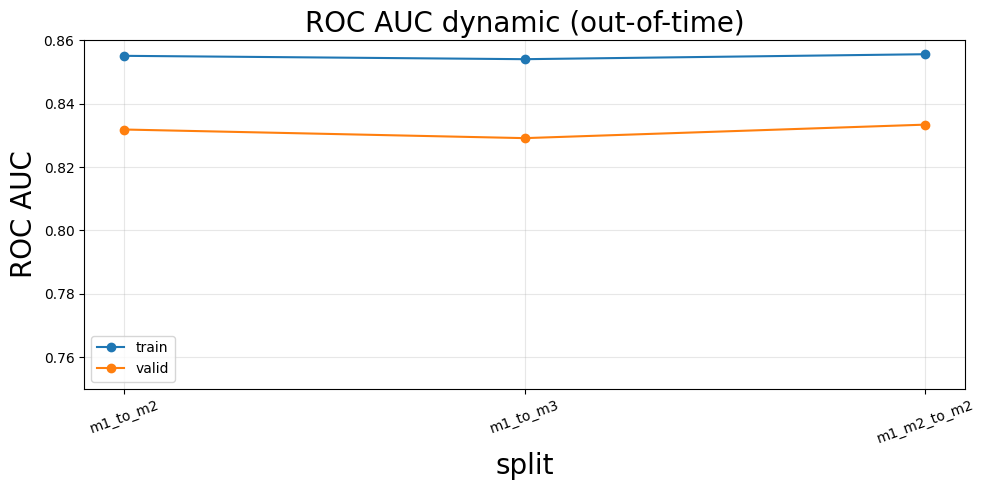

In [127]:
fig, ax = plt.subplots(figsize=(10, 5))
fontsize = 20
plot_df = results_df.copy()

ax.plot(plot_df['fold'], plot_df['train_auc'], marker="o", label='train')
ax.plot(plot_df['fold'], plot_df['vaid_auc'], marker="o", label='valid')

ax.set_ylim(0.75, 0.86)
ax.set_xlabel("split", fontsize= fontsize)
ax.set_ylabel("ROC AUC", fontsize=fontsize)
ax.set_title("ROC AUC dynamic (out-of-time)", fontsize=fontsize)
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [125]:
results_df

,fold,train_n,valid_n,train_auc,vaid_auc
0,m1_to_m2,335285,340153,0.855107,0.831843
1,m1_to_m3,335285,345123,0.854048,0.829121
2,m1_m2_to_m2,675438,345123,0.855613,0.833379
